First 5 Rows:
      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD  TAX  PTRATIO  \
0  0.00632  18.0   2.31   0.0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07   0.0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07   0.0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18   0.0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18   0.0  0.458  7.147  54.2  6.0622    3  222     18.7   

        B  LSTAT  MEDV  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90    NaN  36.2  

Dataset Shape:
(506, 14)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     486 non-null    float64
 1   ZN       486 non-null    float64
 2   INDUS    486 non-null    float64
 3   CHAS     486 n

C:\Users\akank\AppData\Local\Temp\ipykernel_19760\2642888990.py:33: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["INDUS"].fillna(df["INDUS"].mean(), inplace=True)
C:\Users\akank\AppData\Local\Temp\ipykernel_19760\2642888990.py:36: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

F

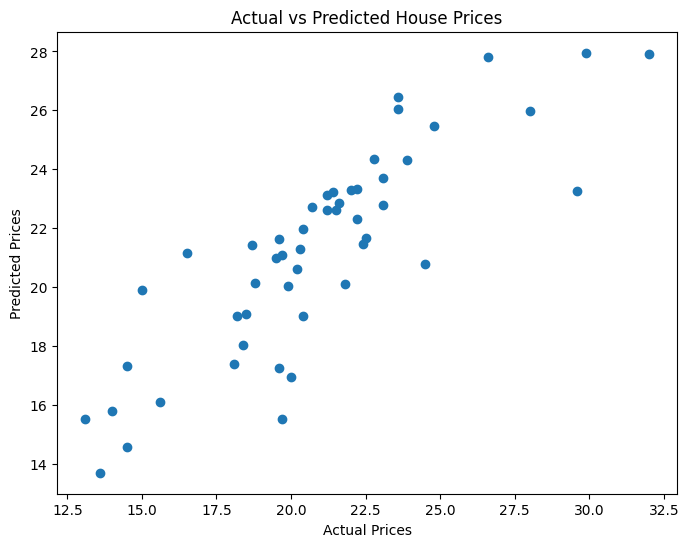

In [2]:
# Data Analytics I
# Linear Regression Model for House Price Prediction

# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Step 2: Load Dataset
df = pd.read_csv("housing_data.csv", na_values="NA")

# Step 3: Display Dataset Information
print("First 5 Rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nDataset Info:")
print(df.info())

# Step 4: Check Missing Values
print("\nMissing Values:")
print(df.isnull().sum())

# Step 5: Fill Missing Values Column-Wise

# INDUS is continuous numerical column -> mean
df["INDUS"].fillna(df["INDUS"].mean(), inplace=True)

# AGE is continuous numerical column -> mean
df["AGE"].fillna(df["AGE"].mean(), inplace=True)

# LSTAT is continuous numerical column -> mean
df["LSTAT"].fillna(df["LSTAT"].mean(), inplace=True)

# CHAS is binary column (0/1) -> mode
df["CHAS"].fillna(df["CHAS"].mode()[0], inplace=True)

# Step 6: Verify Missing Values Removed
print("\nMissing Values After Filling:")
print(df.isnull().sum())

# Step 7: Outlier Detection and Removal using IQR Method
# Apply only on continuous numerical columns

outlier_columns = [
    "CRIM", "ZN", "INDUS", "NOX", "RM",
    "AGE", "DIS", "TAX", "PTRATIO",
    "B", "LSTAT", "MEDV"
]

for col in outlier_columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df = df[
        (df[col] >= lower_bound) &
        (df[col] <= upper_bound)
    ]

print("\nShape After Outlier Removal:")
print(df.shape)

# Step 8: Separate Features and Target
X = df.drop("MEDV", axis=1)
y = df["MEDV"]

# Step 9: Split Dataset into Training and Testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Step 10: Create Linear Regression Model
model = LinearRegression()

# Step 11: Train Model
model.fit(X_train, y_train)

# Step 12: Predict House Prices
y_pred = model.predict(X_test)

# Step 13: Model Evaluation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nModel Evaluation:")

print("Mean Absolute Error :", mae)
print("Mean Squared Error :", mse)
print("Root Mean Squared Error :", rmse)
print("R2 Score :", r2)

# Step 14: Actual vs Predicted Values
comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

print("\nActual vs Predicted Prices:")
print(comparison.head(10))

# Step 15: Scatter Plot
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")

plt.title("Actual vs Predicted House Prices")

plt.show()